# Exploratory Data Analysis

In [41]:
# IMPORTS
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
import psycopg2

In [42]:
conn = psycopg2.connect(dbname="project_db", user="postgres", host="localhost", password="postgres")
cur = conn.cursor()

cur.execute("SELECT * FROM dataset")

rows = cur.fetchall()
colnames = [desc[0] for desc in cur.description]

df = pd.DataFrame(rows, columns=colnames)
df

,id,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,source_split
0,1,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,Unknown,Male,2174,0,40,United-States,<=50K,train
1,2,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,train
2,3,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Unknown,0,0,40,United-States,<=50K,train
3,4,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,Unknown,Unknown
4,5,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48823,48824,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,female,0,0,36,United-States,<=50K,test
48824,48825,64,Unknown,321403,HS-grad,9,Widowed,Unknown,Other-relative,Black,Male,0,0,40,United-States,<=50K,test
48825,48826,38,Private,374983,BACHELORS,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K,test
48826,48827,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K,test


In [43]:
print(df.shape)
df.columns

(48828, 17)


Index(['id', 'age', 'workclass', 'fnlwgt', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'race', 'sex',
       'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
       'income', 'source_split'],
      dtype='object')

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48828 entries, 0 to 48827
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              48828 non-null  int64 
 1   age             48828 non-null  int64 
 2   workclass       48828 non-null  object
 3   fnlwgt          48828 non-null  int64 
 4   education       48828 non-null  object
 5   education_num   48828 non-null  int64 
 6   marital_status  48828 non-null  object
 7   occupation      48828 non-null  object
 8   relationship    48828 non-null  object
 9   race            48828 non-null  object
 10  sex             48828 non-null  object
 11  capital_gain    48828 non-null  int64 
 12  capital_loss    48828 non-null  int64 
 13  hours_per_week  48828 non-null  int64 
 14  native_country  48828 non-null  object
 15  income          48828 non-null  object
 16  source_split    48828 non-null  object
dtypes: int64(7), object(10)
memory usage: 6.3+ MB


In [45]:
df.describe()

,id,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,48828.000000,48828.000000,4.882800e+04,48828.000000,48828.000000,48828.000000,48828.000000
mean,24414.500000,38.616470,1.894423e+05,10.078172,1079.377017,87.527402,40.422913
std,14095.573809,13.575536,1.044670e+05,2.570523,7453.064923,403.059600,12.391345
min,1.000000,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,12207.750000,28.000000,1.185822e+05,9.000000,0.000000,0.000000,40.000000
50%,24414.500000,37.000000,1.782510e+05,10.000000,0.000000,0.000000,40.000000
75%,36621.250000,47.000000,2.357860e+05,12.000000,0.000000,0.000000,45.000000
max,48828.000000,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [46]:
print("Missing Values:\n", df.isna().sum())

Missing Values:
 id                0
age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
source_split      0
dtype: int64


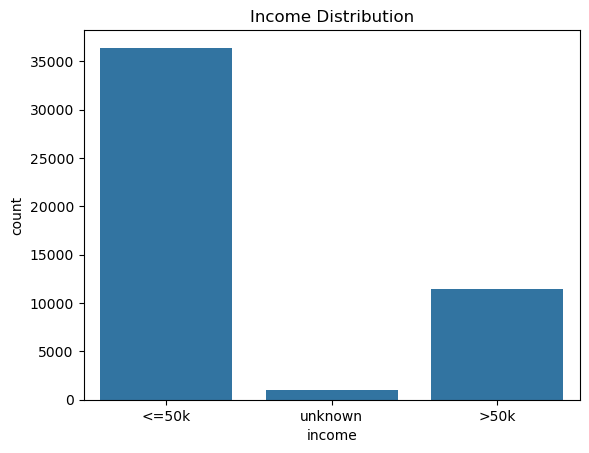

In [ ]:
# Income distribution

#quick fixes data engineer missed
df['income'] = df['income'].str.replace("income", "").str.strip().str.lower()

sns.countplot(data=df, x='income')

plt.title("Income Distribution")

plt.show()

### Analysis:
- Incomes under 50k are more predominant;
- Very low distribution in the high income bracket 
- Relatively low dist. of unknown income values, non-issue.

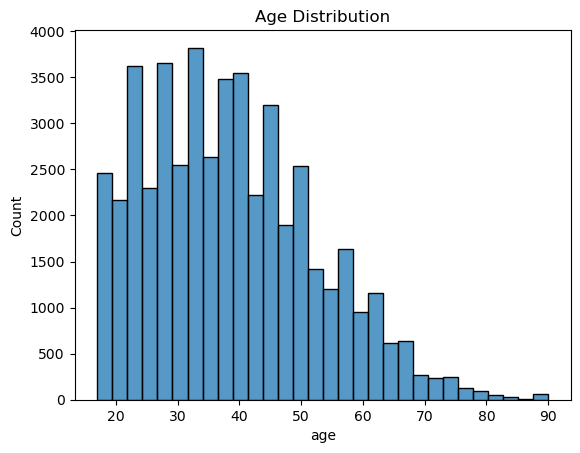

In [48]:
# Age Distribution
sns.histplot(df['age'], bins=30)

plt.title("Age Distribution")

plt.show()

### Analysis:
- Age distribution is clearly right-skewed, with most age inputs between 20-50.

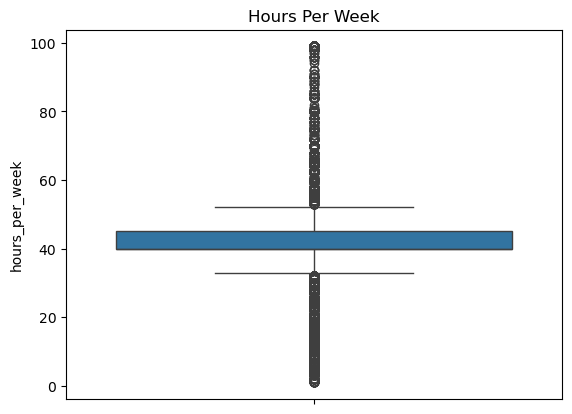

In [49]:
# Hours Worked Per Week
sns.boxplot(data=df, y='hours_per_week')

plt.title("Hours Per Week")

plt.show()

### Analysis
- Difficult to analyse, considering the notable amount of outliers, compared to the low variance box
- Some outliers may be unrealistic (eg. 100)
- ``IQR`` is short, varying between ~40 and ~45

In [67]:
df['workclass'].unique()

array(['state-gov', 'self-emp-not-inc', 'private', 'federal-gov',
       'local-gov', 'unknown', 'self-emp-inc', 'without-pay',
       'never-worked'], dtype=object)

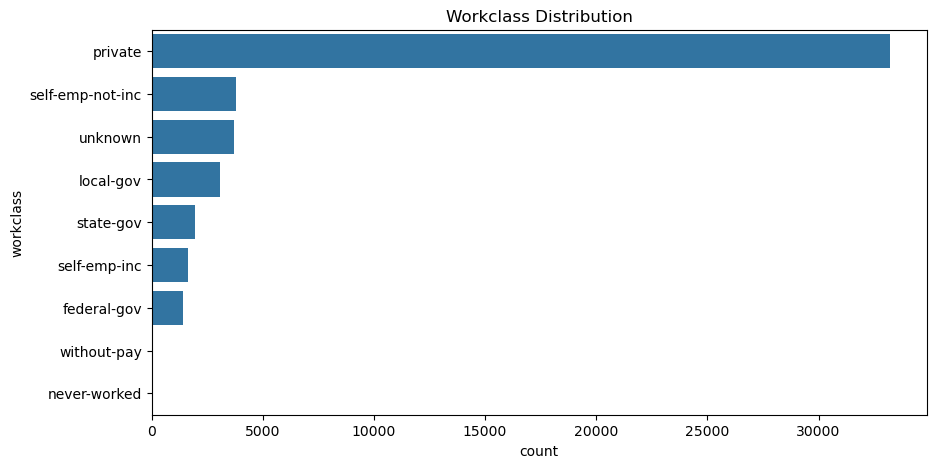

In [ ]:
# quick fixes data engineer missed
df['workclass'] = df['workclass'].str.strip().str.lower().replace("state gov", "state-gov")

# Workclass Distribution

plt.figure(figsize=(10,5))

sns.countplot(data=df, y='workclass', order = df['workclass'].value_counts().index)


plt.title("Workclass Distribution")

plt.show()

### Analysis:
- Heavily right-skewed
- Most values in "private"
- No workclass data relative to ``"without-pay"`` / ``"never-worked"`` 

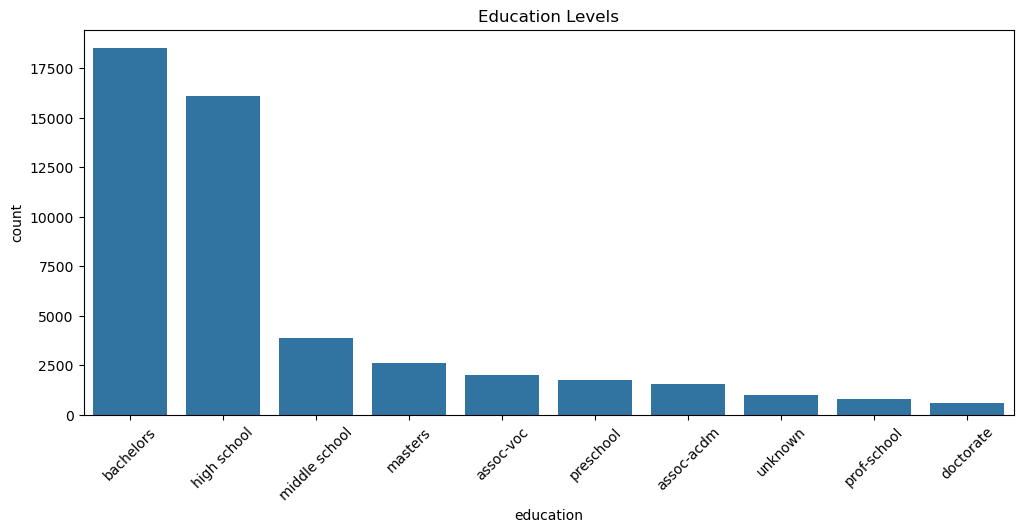

In [85]:
# quick fixes data engineer missed
df['education'] = (
    df['education']
    .str.strip()
    .str.lower()
    .replace(["bachelor's", "some-college"], "bachelors")
    .replace(["hs grad", "hs-grad", "12th"], "high school") 
    .replace(["11th", "10th", "9th"], "middle school")
    .replace(["7th-8th", "5th-6th", "1st-4th"], "preschool")
    )


# Education levels
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x='education',
    order=df['education'].value_counts().index
)

plt.xticks(rotation=45)

plt.title("Education Levels")

plt.show()

### Analysis:
- To be expected: A lot of bachelors and high school diplomas
- More than double the people without proper education **(pre-school)** than those with doctorates
    - This could be due to lack of education as a societal issue **OR**
    - A display of difficulty in doctorate level education.

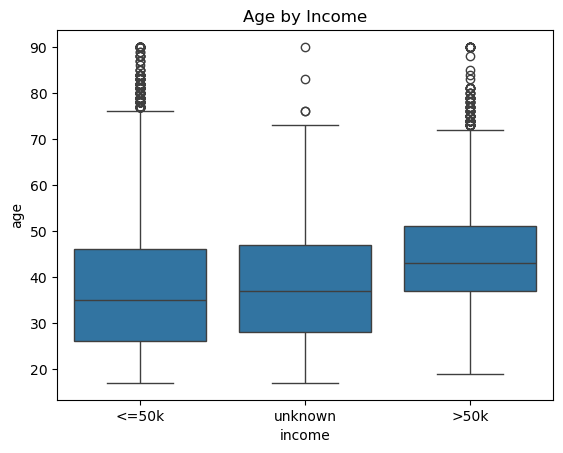

In [75]:
# Age and Income relation
sns.boxplot(
    data=df,
    x='income',
    y='age'
)

plt.title("Age by Income")

plt.show()

### Analysis:
- Higher income seems related to higher age:
    - Potentially due to more time in their field
- Lower/Unknown income data seems more prodominant in the lower age groups.

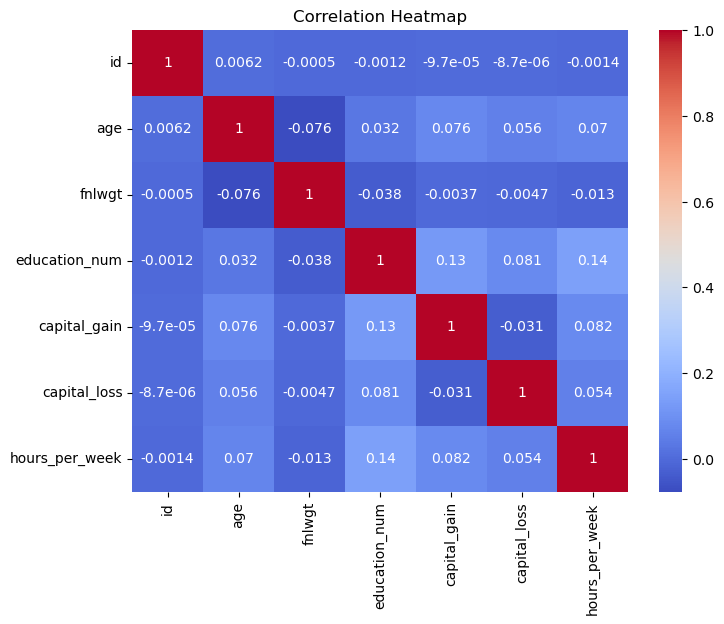

In [80]:
# Correlation Heatmap
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(8,6))

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

### Analysis:
- According to the correlation heatmap, none of the numerical features are directly correlated.
    - For this reason, i will not be deeply analising more scatterplot pairs.
    - For further justification, check pairplot below. 

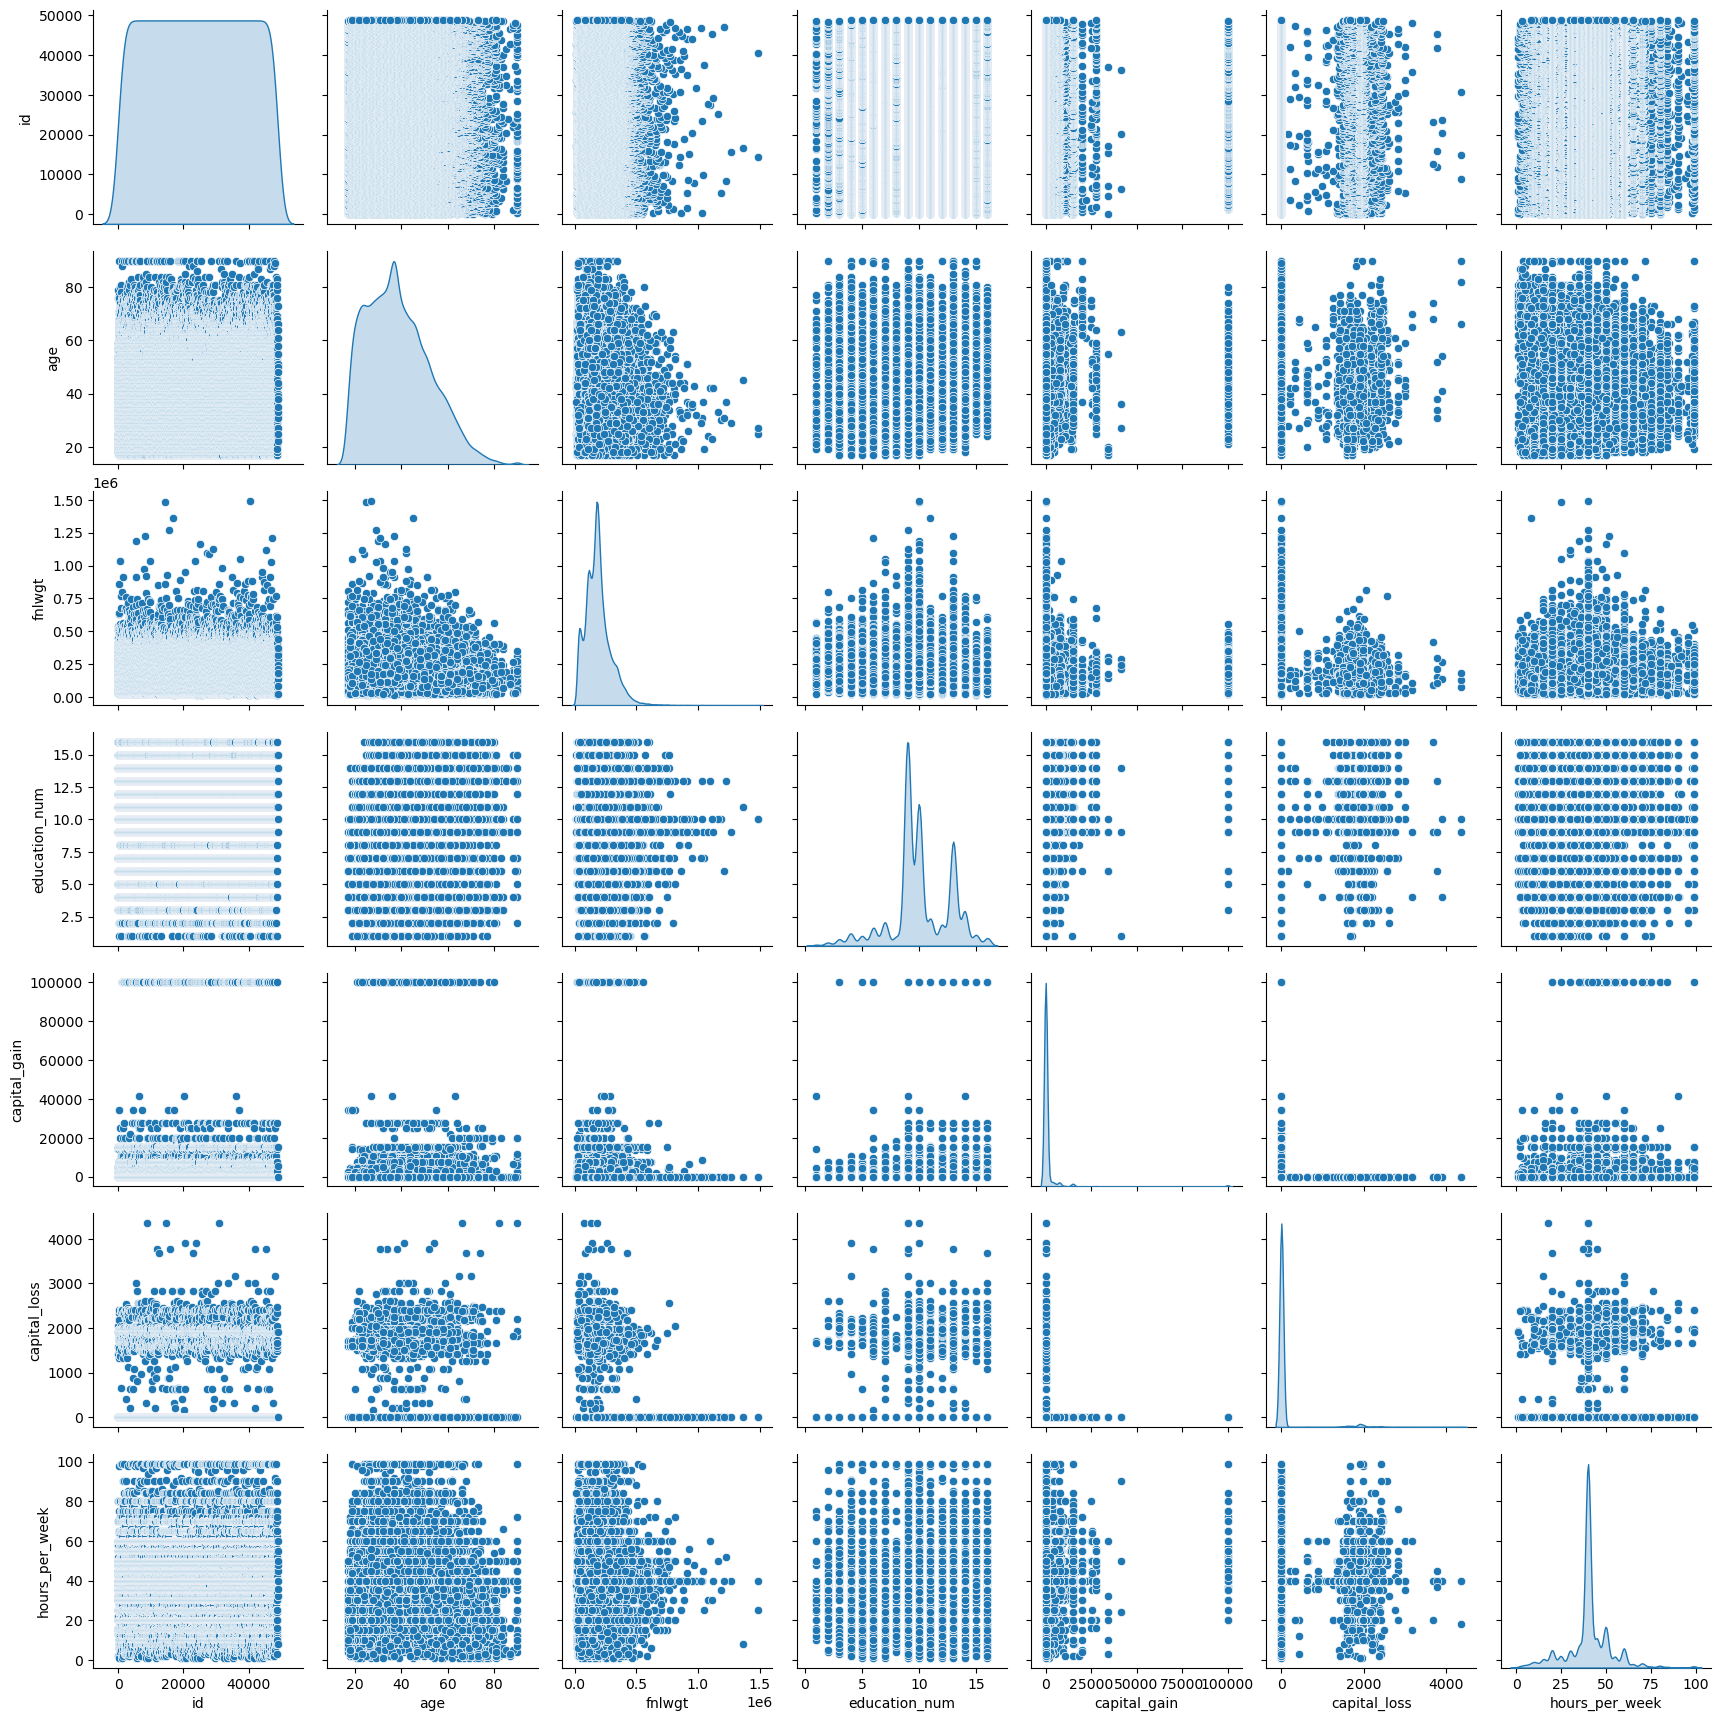

In [82]:
sns.pairplot(
    data=df,
    diag_kind='kde'
)